### A. Research Question

**Project:** Logistic Regression on an Environmental Microbial Dataset

**Research Question:** Can a logistic regression model be constructed on the environmental dataset?

**Null Hypothesis:** A logistic regression model cannot be constructed on the environmental dataset.

**Alternative Hypothesis:** A logistic regression model can be constructed on the environmental dataset at an accuracy greater than 70%.

Environmental monitoring is used to identify microbial conditions within manufacturing environments and is an important component of contamination control in manufacturing operations (U.S. Food and Drug Administration, 2004). Microbial contamination can have significant operational consequences, including product recalls (Wong et al., 2000). Elevated results can indicate locations or time periods where additional monitoring, cleaning, or preventive attention may be valuable.

Logistic regression was selected as the primary technique because the outcome can be represented as a binary variable: acceptable results are classified as 0 and Alert/Action results are classified as 1. Logistic regression is an established statistical technique for modeling binary outcomes (Hosmer et al., 2013). Logistic regression has also been applied in previous research to predict microbial outcomes (Dong et al., 2009).

### B. Data Collection

The dataset used for this analysis contains 10,531 synthetic environmental monitoring microbiology observations representing routine manufacturing-area monitoring (Balakier, 2026). The variables describe sampling department, area, site, location, facility zone, sampling frequency, sample type, sample date, colony-forming unit (CFU) result, and Alert/Action classification.

The data were generated as a synthetic dataset designed to represent the structure and characteristics of environmental monitoring records. Synthetic data allowed realistic sampling and microbial-result patterns to be analyzed without exposing confidential or proprietary manufacturing information.

One advantage of this data-gathering methodology is that synthetic data can represent realistic environmental monitoring scenarios while avoiding disclosure of confidential information. One disadvantage is that synthetic observations may not perfectly reproduce the relationships and variability found in actual manufacturing data.

A challenge in developing the synthetic dataset was creating sufficient variation across sampling locations, time periods, and microbial results to support predictive modeling. The final dataset contains multiple departments, areas, sampling sites, facility zones, and seasons. It contains 10,531 observations ranging from January 2023 through April 2026.


### C. Data Extraction and Preparation

Python was used to extract, inspect, and prepare the data for analysis. The analysis was performed in a Jupyter Notebook using pandas for data manipulation, NumPy for numerical operations, Matplotlib for visualization, and scikit-learn for preprocessing and machine learning.

The dataset was imported from a CSV file into a pandas DataFrame. Initial validation included reviewing the dataset dimensions, data types, missing values, duplicate records, date range, and categorical variables. These checks were performed to verify that the dataset was suitable for analysis before constructing the models.

In [1]:
#Imports and reproducibility



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score
)

RANDOM_STATE = 42

#A fixed random state of 42 was used to make the train/test split and model results reproducible.

#Loading the cleaned modeling dataset

df = pd.read_csv("environmental_monitoring_microbiology_2023_2026.csv")
print(df.shape)
df.head()

(10531, 18)


,Mid,DepartmentName,AreaName,SiteName,Location,Alert,Action,SampleDate,CFU,Zone,Frequency,Action/Alert Count,Air_AirUnits.AirType,Year,Month,MonthName,DayOfYear,Season
0,46243,Filling and Assembly,WC 5 - East,R30,Staging,30.0,40.0,2023-08-09,6.0,Clean,Monthly,NaN,(CFU/160L),2023,8,August,221,Summer
1,46272,Filling and Assembly,WC 5 - East,R30,Staging,30.0,40.0,2023-08-09,8.0,Clean,Monthly,NaN,(CFU/160L),2023,8,August,221,Summer
2,46287,Filling and Assembly,WC 5 - East,R30,Staging,30.0,40.0,2023-08-09,8.0,Clean,Monthly,NaN,(CFU/160L),2023,8,August,221,Summer
3,46331,Filling and Assembly,WC 5 - East,R30,Staging,30.0,40.0,2023-08-09,11.0,Clean,Monthly,NaN,(CFU/160L),2023,8,August,221,Summer
4,46332,Filling and Assembly,WC 5 - East,R30,Staging,30.0,40.0,2023-08-09,15.0,Clean,Monthly,NaN,(CFU/160L),2023,8,August,221,Summer


### Validate the cleaned dataset

These checks verify the cleaned data.


In [2]:
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

df.head()

df["SampleDate"] = pd.to_datetime(df["SampleDate"])

print("Date range:")
print(df["SampleDate"].min(), "to", df["SampleDate"].max())

categorical_columns = [
    "DepartmentName",
    "AreaName",
    "SiteName",
    "Location",
    "Zone",
    "Frequency",
    "Air_AirUnits.AirType",
    "Season"
]

print("\nUnique values:")
print(df[categorical_columns].nunique())

Dataset shape: (10531, 18)
Duplicate rows: 0

Missing values:
Mid                         0
DepartmentName              0
AreaName                    0
SiteName                    0
Location                    0
Alert                     794
Action                    794
SampleDate                  0
CFU                         0
Zone                        0
Frequency                   0
Action/Alert Count      10172
Air_AirUnits.AirType        0
Year                        0
Month                       0
MonthName                   0
DayOfYear                   0
Season                      0
dtype: int64

Data types:
Mid                       int64
DepartmentName              str
AreaName                    str
SiteName                    str
Location                    str
Alert                   float64
Action                  float64
SampleDate                  str
CFU                     float64
Zone                        str
Frequency                   str
Action/Alert Count  

In [3]:
#Date and seasonality

print(df[["SampleDate", "Year", "Month", "Season"]].dtypes)
df[["SampleDate", "Year", "Month", "Season"]].head()

# bringing Site and Location together to create a new column called Site_Location
df["Site_Location"] = (df["SiteName"].astype(str) + " - " +df["Location"].astype(str))

df["Elevated_Result"] = (df["Action/Alert Count"].isin(["Alert", "Action"]).astype(int))

print(df["Elevated_Result"].value_counts())
print(df["Elevated_Result"].value_counts(normalize=True) * 100)

SampleDate    datetime64[us]
Year                   int64
Month                  int64
Season                   str
dtype: object
Elevated_Result
0    10172
1      359
Name: count, dtype: int64
Elevated_Result
0    96.591017
1     3.408983
Name: proportion, dtype: float64


SiteName and Location were combined into a Site_Location variable because location identifiers may occur at multiple sampling sites. A binary target named Elevated_Result was then created. Alert and Action observations were assigned a value of 1, while acceptable observations were assigned a value of 0. Of the 10,531 observations, 359 (3.41%) were elevated and 10,172 (96.59%) were acceptable.

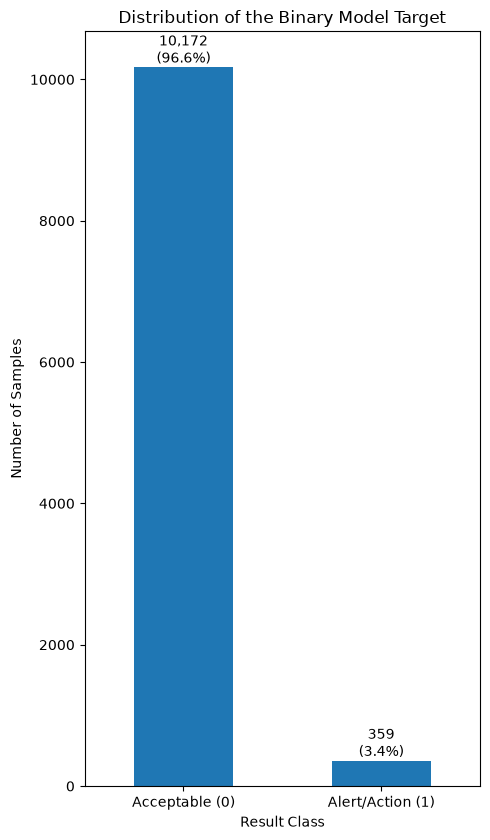

In [4]:
class_summary = df["Elevated_Result"].value_counts().sort_index()
class_percent = df["Elevated_Result"].value_counts(normalize=True).sort_index() * 100

ax = class_summary.plot(
    kind="bar",
    figsize=(5, 8.5)
)

plt.title("Distribution of the Binary Model Target")
plt.xlabel("Result Class")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Acceptable (0)", "Alert/Action (1)"], rotation=0)

for i, value in enumerate(class_summary):
    plt.text(
        i,
        value,
        f"{value:,}\n({class_percent.iloc[i]:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


Only fields reasonably known before the microbial result is available are predictors. CFU, the alert/action thresholds, and the target-defining result field are explicitly excluded because they either reveal the observed result or directly determine its classification. Mid is an identifier, while raw or redundant date fields are excluded for parsimony.

The hierarchical sampling context is represented using Department, Area, and a combined Site_Location feature. SiteName and Location were combined because a location identifier may occur in more than one Site.


In [5]:
features = [
    "DepartmentName",
    "AreaName",
    "Site_Location",
    "Zone",
    "Frequency",
    "Air_AirUnits.AirType",
    "Year",
    "Season"
]

leakage_columns = [
    "CFU",
    "Alert",
    "Action",
    "Action/Alert Count"
]

excluded_columns = [
    "Mid",
    "SampleDate",
    "SiteName",
    "Location",
    "Month",
    "MonthName",
    "DayOfYear"
]

print("Final predictors:")
print(features)

print("\nExcluded leakage variables:")
print(leakage_columns)

print("\nOther excluded columns:")
print(excluded_columns)


Final predictors:
['DepartmentName', 'AreaName', 'Site_Location', 'Zone', 'Frequency', 'Air_AirUnits.AirType', 'Year', 'Season']

Excluded leakage variables:
['CFU', 'Alert', 'Action', 'Action/Alert Count']

Other excluded columns:
['Mid', 'SampleDate', 'SiteName', 'Location', 'Month', 'MonthName', 'DayOfYear']


One advantage of using Python and pandas for data preparation is that the preparation steps can be performed consistently and reproduced directly from the original CSV file. The scikit-learn preprocessing pipeline also ensures that the same transformations are applied during model training and testing. One disadvantage is that categorical variables require additional preprocessing before they can be used by the machine-learning models. One-hot encoding was therefore used later in the modeling pipeline to convert categorical predictors into a numerical representation.

### D. Analysis

The analysis consisted of exploratory analysis followed by classification modeling. Elevated-result rates were first examined across environmental monitoring characteristics to identify patterns in the dataset. Logistic regression was then used as the primary predictive technique. Because the elevated class represented only 3.41% of the observations, a majority-class baseline, balanced logistic regression, and Random Forest model were also evaluated to provide context for the logistic regression results. Because the dataset is highly imbalanced, model performance was evaluated using measures beyond overall accuracy. Precision-recall analysis is particularly informative when evaluating binary classifiers on imbalanced datasets (Saito & Rehmsmeier, 2015).

In [6]:
def elevated_summary(data, column):
    summary = (
        data.groupby(column)["Elevated_Result"]
        .agg(["count", "sum", "mean"])
    )

    summary.columns = ["Sample_Count", "Elevated_Count", "Elevated_Rate"]

    return summary.sort_values("Elevated_Rate", ascending=False)


zone_summary = elevated_summary(df, "Zone")
department_summary = elevated_summary(df, "DepartmentName")
season_summary = elevated_summary(df, "Season")
area_summary = elevated_summary(df, "AreaName")
site_Location_summary = elevated_summary(df, "Site_Location")


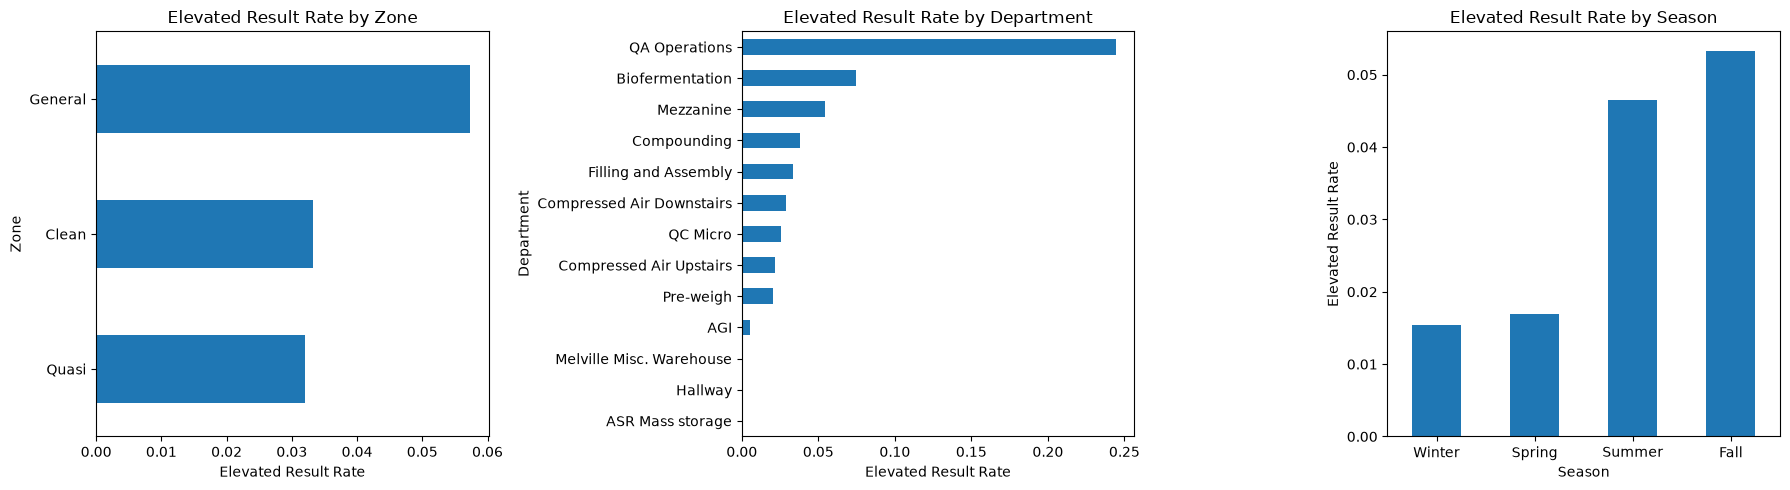

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

zone_summary.sort_values("Elevated_Rate").plot(
    kind="barh",
    y="Elevated_Rate",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Elevated Result Rate by Zone")
axes[0].set_xlabel("Elevated Result Rate")
axes[0].set_ylabel("Zone")


department_summary.sort_values("Elevated_Rate").plot(
    kind="barh",
    y="Elevated_Rate",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Elevated Result Rate by Department")
axes[1].set_xlabel("Elevated Result Rate")
axes[1].set_ylabel("Department")


season_order = ["Winter", "Spring", "Summer", "Fall"]

season_summary.loc[season_order].plot(
    kind="bar",
    y="Elevated_Rate",
    legend=False,
    ax=axes[2]
)

axes[2].set_title("Elevated Result Rate by Season")
axes[2].set_xlabel("Season")
axes[2].set_ylabel("Elevated Result Rate")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [8]:
area_top15 = area_summary.head(15).copy()
site_Location_top15 = site_Location_summary.head(15).copy()

area_top15["Elevated_Rate"] = (area_top15["Elevated_Rate"] * 100).round(2)
site_Location_top15["Elevated_Rate"] = (site_Location_top15["Elevated_Rate"] * 100).round(2)

print("Area summary - top 15")
display(area_top15)

print("Site summary - top 15")
display(site_Location_top15)

# This describes the elevated result rate by categorical variables such as zone, department, season, area, and site.


Area summary - top 15


,Sample_Count,Elevated_Count,Elevated_Rate
AreaName,,,
ASR Sampling,89,29,32.58
(BF) Room #3,44,5,11.36
Creams Lab #2,101,10,9.90
Creams Lab #1B,43,4,9.30
East Mezzanine,62,5,8.06
(BF) Micro Lab,41,3,7.32
(BF) Room #1,42,3,7.14
(BF) Room #2,42,3,7.14
Eye Products Lab,48,3,6.25


Site summary - top 15


,Sample_Count,Elevated_Count,Elevated_Rate
Site_Location,,,
Reserve Clean Air - By Drop,7,3,42.86
Inside East end - Room Air,47,18,38.30
Inside West end - Room Air,42,11,26.19
By K40 - Near Kettle,16,4,25.00
By K1B - Near Kettle,16,3,18.75
Air Compressor Tanks - By Drop,6,1,16.67
By K MU-02 - Near Kettle,15,2,13.33
By K16 - Near Kettle,15,2,13.33
By K41 - Near Kettle,15,2,13.33


### Train/test split


In [9]:
X = df[features].copy()
y = df["Elevated_Result"].copy()

# Treat Year as categorical
X["Year"] = X["Year"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Positive class in training set:", round(y_train.mean() * 100, 2), "%")
print("Positive class in test set:", round(y_test.mean() * 100, 2), "%")


Training observations: 8424
Testing observations: 2107
Positive class in training set: 3.41 %
Positive class in test set: 3.42 %


In [10]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

print(
    "Baseline accuracy:",
    round(accuracy_score(y_test, dummy_pred) * 100, 2),
    "%"
)

Baseline accuracy: 96.58 %


The data were divided into 80% training and 20% testing sets using stratification. Stratification preserved the approximately 3.41% elevated-result rate in both datasets.

### Pipeline preprocessing



In [11]:
preprocessor = ColumnTransformer(transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), features)])

logistic_model = Pipeline([("preprocessor", preprocessor),("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("Average Precision:", round(average_precision_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Logistic Regression Results
Accuracy: 0.9663
Precision: 1.0
Recall: 0.0139
F1 Score: 0.0274
Average Precision: 0.1619

Confusion Matrix:
[[2035    0]
 [  71    1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2035
           1       1.00      0.01      0.03        72

    accuracy                           0.97      2107
   macro avg       0.98      0.51      0.51      2107
weighted avg       0.97      0.97      0.95      2107



#### Logistic Regression:

Logistic regression was selected because the research question requires prediction of a binary outcome. One advantage of logistic regression is that it provides an interpretable and established method for estimating binary outcomes (Hosmer et al., 2013). One disadvantage is that its default classification behavior can perform poorly when classes are severely imbalanced, as demonstrated by the low recall for elevated results in this analysis.

In [12]:
balanced_logistic = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

balanced_logistic.fit(X_train, y_train)

balanced_pred = balanced_logistic.predict(X_test)
balanced_prob = balanced_logistic.predict_proba(X_test)[:, 1]

print("Balanced Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, balanced_pred), 4))
print("Precision:", round(precision_score(y_test, balanced_pred), 4))
print("Recall:", round(recall_score(y_test, balanced_pred), 4))
print("F1 Score:", round(f1_score(y_test, balanced_pred), 4))
print("Average Precision:", round(average_precision_score(y_test, balanced_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, balanced_pred))

print("\nClassification Report:")
print(classification_report(y_test, balanced_pred))

Balanced Logistic Regression Results
Accuracy: 0.7513
Precision: 0.0815
Recall: 0.6111
F1 Score: 0.1438
Average Precision: 0.151

Confusion Matrix:
[[1539  496]
 [  28   44]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.85      2035
           1       0.08      0.61      0.14        72

    accuracy                           0.75      2107
   macro avg       0.53      0.68      0.50      2107
weighted avg       0.95      0.75      0.83      2107



#### Baseline Model Interpretation: 
The majority-class baseline achieved 96.58% accuracy by predicting every observation as acceptable. The standard logistic regression achieved 96.63% accuracy, only 0.05 percentage points higher than the baseline. This shows that the high accuracy of the logistic regression model was largely driven by the severe class imbalance rather than strong identification of elevated results.

#### Balanced logistic regression

The balanced logistic regression was included to evaluate whether weighting the minority class could improve detection of elevated results. Its primary advantage is improved sensitivity to the minority class without changing the underlying observations. Its disadvantage is that increasing sensitivity can substantially increase false-positive classifications.


In [13]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall:", round(recall_score(y_test, rf_pred), 4))
print("F1 Score:", round(f1_score(y_test, rf_pred), 4))
print("Average Precision:", round(average_precision_score(y_test, rf_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results
Accuracy: 0.8083
Precision: 0.0871
Recall: 0.4861
F1 Score: 0.1477
Average Precision: 0.1094

Confusion Matrix:
[[1668  367]
 [  37   35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      2035
           1       0.09      0.49      0.15        72

    accuracy                           0.81      2107
   macro avg       0.53      0.65      0.52      2107
weighted avg       0.95      0.81      0.87      2107



#### Random Forest:

Random Forest was included as a comparison technique because it combines multiple decision trees and can capture complex relationships among predictors (Breiman, 2001). One advantage of Random Forest is its ability to model nonlinear relationships and interactions without requiring them to be specified in advance. One disadvantage is that the resulting model is less directly interpretable than logistic regression. In this analysis, Random Forest achieved 80.83% accuracy and 48.61% recall for elevated results.

In [14]:
# Comparing all three models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, balanced_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, balanced_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, balanced_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, balanced_pred),
        f1_score(y_test, rf_pred)
    ],
    "Average Precision": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, balanced_prob),
        average_precision_score(y_test, rf_prob)
    ]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,Average Precision
0,Logistic Regression,0.9663,1.0000,0.0139,0.0274,0.1619
1,Balanced Logistic Regression,0.7513,0.0815,0.6111,0.1438,0.1510
2,Random Forest,0.8083,0.0871,0.4861,0.1477,0.1094


### Three models

The standard logistic regression achieved the highest overall accuracy at 96.63%; however, its recall was only 1.39%, indicating that it failed to identify nearly all elevated results. The balanced logistic regression substantially improved recall to 61.11%, although this reduced accuracy and precision. The Random Forest achieved the highest F1 score of 14.77% but detected fewer elevated results than the balanced logistic regression. Because identifying elevated results is more important than maximizing overall accuracy in this application, the balanced logistic regression provided the most useful recall among the tested models.

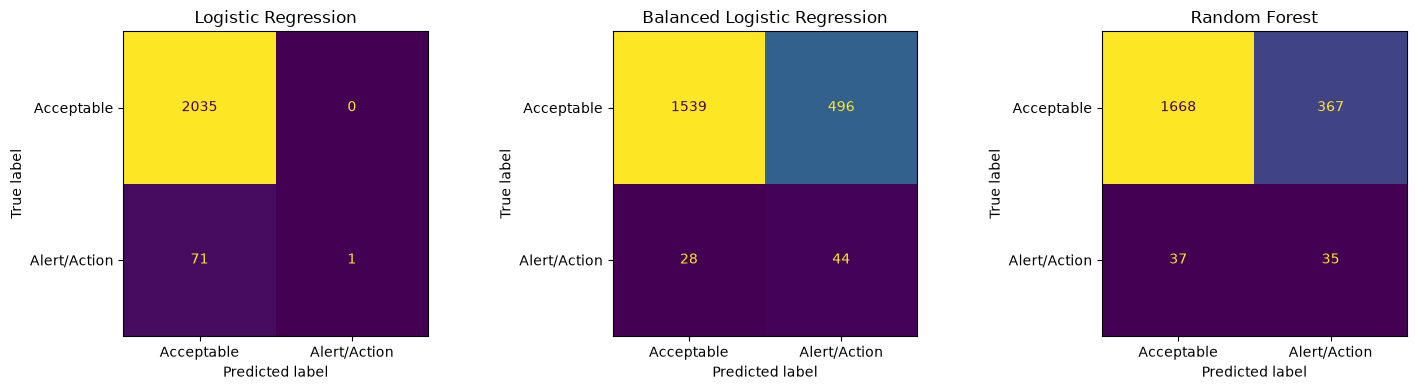

In [15]:
# Confusion Matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Acceptable", "Alert/Action"], ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, balanced_pred, display_labels=["Acceptable", "Alert/Action"], ax=axes[1], colorbar=False)
axes[1].set_title("Balanced Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=["Acceptable", "Alert/Action"], ax=axes[2], colorbar=False)
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrices show that standard logistic regression rarely predicted the elevated class, identifying only 1 of 72 elevated samples. The balanced logistic regression identified the greatest number of elevated samples, while the Random Forest provided a middle ground between elevated result detection and overall accuracy.

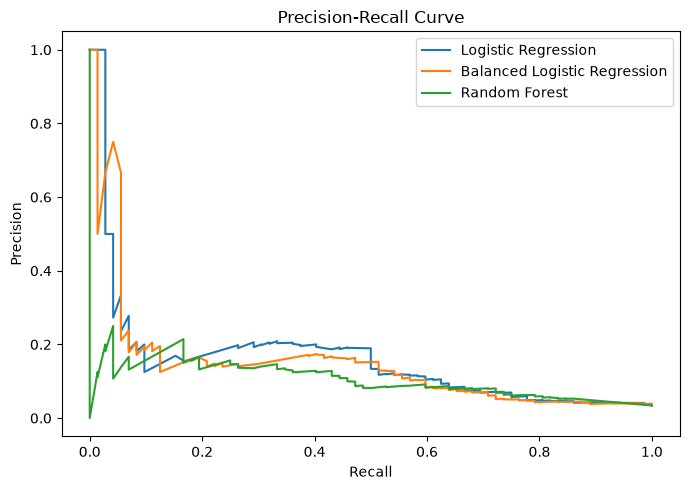

In [16]:
lr_precision, lr_recall, _ = precision_recall_curve(y_test, y_prob)
bal_precision, bal_recall, _ = precision_recall_curve(y_test, balanced_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))

plt.plot(lr_recall, lr_precision, label="Logistic Regression")
plt.plot(bal_recall, bal_precision, label="Balanced Logistic Regression")
plt.plot(rf_recall, rf_precision, label="Random Forest")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

### Precision Recall Curve Interpretation: 

All three models had difficulty distinguishing elevated results from acceptable results. Precision decreased as recall increased, demonstrating the tradeoff between identifying more Alert/Action results and generating additional false positives. Overall, the relatively low precision across the curves reflects the difficulty of predicting the minority elevated-result class.

In [17]:
feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = logistic_model.named_steps[
    "model"
].coef_[0]

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_table = coefficient_table.sort_values(
    "Coefficient",
    ascending=False
)

coefficient_table["Feature"] = (
    coefficient_table["Feature"]
    .str.replace("categorical__", "", regex=False)
)

display(coefficient_table.head(15).round(3))
display(coefficient_table.tail(15).round(3))

,Feature,Coefficient
279,Site_Location_R02 - Filling Room,1.258
239,Site_Location_LFH 895 - HEPA Hood,1.232
173,Site_Location_By K51 - Near Kettle,1.212
137,Site_Location_By K1B - Near Kettle,1.192
31,AreaName_ASR Sampling,1.174
283,Site_Location_R03 - Filling Room,1.168
328,Site_Location_R28 - Air Nozzle,1.154
11,DepartmentName_QA Operations,1.139
133,Site_Location_By K16 - Near Kettle,1.129
275,Site_Location_R01 - Filling Room,1.036


,Feature,Coefficient
298,Site_Location_R07 - Filling Room,-0.622
313,Site_Location_R11 - Staging,-0.635
387,Season_Spring,-0.671
331,Site_Location_R28 - Staging,-0.706
292,Site_Location_R05 - Staging,-0.709
389,Season_Winter,-0.710
215,Site_Location_Center of Room - Center of Room,-0.728
37,AreaName_Creams Lab #4,-0.735
19,AreaName_2nd Floor Hallway,-0.851
282,Site_Location_R03 - Assembly,-0.902


### Logistic Regression Coefficient Interpretation: 

The strongest positive coefficients were associated with several specific site-location combinations, including filling-room, HEPA hood, and near-kettle sampling locations. Positive coefficients indicate that these categories were associated with a higher predicted probability of an Alert/Action result. Negative coefficients indicate categories associated with a lower predicted probability. Because the predictors are categorical and some location variables are hierarchical, these coefficients should be interpreted as model associations rather than causal effects.

In [18]:
results_percent = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score", "Average Precision"]:
    results_percent[column] = (results_percent[column] * 100).round(2)

display(results_percent)

,Model,Accuracy,Precision,Recall,F1 Score,Average Precision
0,Logistic Regression,96.63,100.00,1.39,2.74,16.19
1,Balanced Logistic Regression,75.13,8.15,61.11,14.38,15.10
2,Random Forest,80.83,8.71,48.61,14.77,10.94


### Model Comparison: 

The standard logistic regression achieved the highest accuracy at 96.63%, but its recall of 1.39% showed that it identified almost none of the elevated results. The balanced logistic regression achieved the highest recall at 61.11%, while the Random Forest achieved the highest F1 score at 14.77%. For identifying elevated environmental monitoring results, the balanced logistic regression provided the strongest sensitivity, although its low precision indicates that many acceptable samples were also flagged.


### Hypothesis Result: 

The standard logistic regression achieved 96.63% accuracy on the held-out test data, exceeding the predefined 70% threshold. Therefore, the alternative hypothesis was supported according to the stated criterion. However, the 96.58% majority-class baseline achieved nearly identical accuracy, and the logistic regression identified only 1.39% of elevated results. Therefore, accuracy alone did not indicate practically useful predictive performance.



### E. Data Summary and Implications

The analysis demonstrated that a logistic regression model could be constructed on the environmental dataset with greater than 70% accuracy. The standard logistic regression achieved 96.63% accuracy, supporting the alternative hypothesis according to the predefined criterion. However, the majority-class baseline achieved 96.58% accuracy, and standard logistic regression correctly identified only 1 of the 72 elevated results in the test set. This demonstrates that overall accuracy was not sufficient for evaluating the practical usefulness of the model because elevated results represented only 3.41% of the dataset.

Balanced logistic regression improved elevated-result recall from 1.39% to 61.11%, correctly identifying 44 of 72 elevated observations. This improvement came at the cost of 496 false-positive classifications and precision of 8.15%. Random Forest produced higher overall accuracy of 80.83% and the highest F1 score of 14.77%, but its elevated-result recall of 48.61% was lower than balanced logistic regression. Therefore, balanced logistic regression achieved the highest recall among the tested models and identified the greatest proportion of elevated results.

A limitation of this analysis is that the dataset is synthetic and may not fully represent the relationships and variability found in real manufacturing environmental-monitoring data. In addition, the relatively small number of elevated observations makes prediction of the minority class difficult. Based on the results, balanced logistic regression could be considered as a screening or prioritization tool rather than as an automated decision-making system. Higher-risk predictions could be used to prioritize additional monitoring, cleaning, or investigation while actual microbial test results remain the basis for quality decisions.

Future research could first evaluate the model using a larger real-world or independently generated environmental-monitoring dataset to determine whether the observed relationships generalize beyond the synthetic data. A second direction would be to evaluate additional methods for rare-event classification, such as alternative classification thresholds, resampling methods, or additional machine-learning algorithms, to determine whether elevated-result recall can be improved without producing as many false-positive predictions.

### F. References

Balakier, R. (2026). Environmental monitoring microbial results [Data set]. Kaggle. Retrieved August 30, 2026.

Breiman, L. (2001). Random forests. Machine Learning, 45, 5–32. Retrieved August 30, 2026.

Dong, L., Zhao, X., Wu, Q., & Yang, Y. (2009). Logistic regression for prediction and diagnosis of bacterial regrowth in water distribution system. Transactions of Tianjin University, 15, 371–374. Retrieved August 30, 2026.

Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). Applied logistic regression (3rd ed.). Wiley. Retrieved August 30, 2026.

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. PLOS ONE, 10(3), e0118432. Retrieved August 30, 2026.

U.S. Food and Drug Administration. (2004). Sterile drug products produced by aseptic processing—Current good manufacturing practice: Guidance for industry. Retrieved August 30, 2026.

Wong, S., Street, D., Delgado, S. I., & Klontz, K. C. (2000). Recalls of foods and cosmetics due to microbial contamination reported to the U.S. Food and Drug Administration. Journal of Food Protection, 63(8), 1113–1116. Retrieved August 30, 2026.